# Cluster QC by library: expression dispersion and cluster separation

Two per-cluster metrics, computed **separately within each library**, for the clusterings stored
on `adata_rna.h5ad`:

1. **Median gene coefficient of variation** over the 2000 most expressed genes. For each
   (library, cluster) group and each of those genes, `CV = sd / mean` across the cells in the
   group; the reported number is the median CV over the genes. High CV means the cells assigned
   to that cluster in that library disagree with each other about expression level — a
   heterogeneous or poorly resolved group.
2. **Silhouette score** on `X_pca`, averaged per cluster. A cell's silhouette compares its mean
   distance to its own cluster against the nearest other cluster: `+1` well inside its own
   cluster, `0` on a boundary, negative when it sits closer to a different cluster.

The two answer different questions and are meant to be read together — CV is about *within-group*
spread in expression space, silhouette is about *between-group* geometry in PCA space. A cluster
can be tight in PCA yet transcriptionally noisy, or vice versa.

**Clusterings covered.** `seurat_clusters` and `integrated_snn_res.0.5` are the same 17-cluster
partition, and `cluster_annot` is that partition with cell-type names attached, so the notebook
runs on `cluster_annot` (the 17 clusters, readable labels) and `celltype_call` (the 9-level
cell-type collapse). Both are in `CLUSTER_KEYS` — drop one, or add a `SCT_snn_res.*` column, to
change the scope.

> **Silhouette is reported two ways.** `silhouette_within_library` recomputes the score using only
> that library's cells, so it measures how well the clusters separate *inside* one batch.
> `silhouette_global` scores every cell once against all 30,467 cells and then breaks the result
> out by library, so a library's cells are judged against the clusters as they appear in the
> merged object. The first is the fair per-batch question; the second shows whether a library's
> cells sit where the merged cluster says they should.

In [1]:
from pathlib import Path
import time

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy import sparse
from sklearn.metrics import silhouette_samples

## Configuration

In [2]:
RAW_H5AD = Path(
    r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Data\anndata_export\adata_rna.h5ad"
)
RESULTS_DIR = Path("qc_results")

LIBRARY_KEY = "libraries"
CLUSTER_KEYS = [
    "cluster_annot",
    "celltype_call",
]  # 17 named clusters, then the 9 cell types

N_TOP_GENES = (
    2000  # "most expressed" = highest mean normalised expression across all cells
)
TARGET_SUM = (
    1e4  # per-cell depth normalisation before CV (CV on raw counts tracks depth)
)
EMBEDDING = "X_pca"  # space the silhouette distances are measured in
MIN_CELLS_CV = 2  # a sample sd needs at least two cells
MIN_CELLS_REPORT = (
    10  # groups below this are kept in the tables but masked in the heatmaps
)
RUN_GLOBAL_SILHOUETTE = (
    True  # one O(n^2) pass over all 30,467 cells per clustering (~minutes)
)

SAVE_RESULTS = True

# light-mode chart colors: documented blue ramp (sequential) and blue<->gray<->red (diverging)
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#0d366b"]
)
DIV_BLUE_RED = LinearSegmentedColormap.from_list(
    "div_blue_red", ["#d03b3b", "#e8a99f", "#f0efec", "#9ec5f4", "#2a78d6"]
)
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]
MUTED_INK, SECONDARY_INK = "#898781", "#52514e"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#c3c2b7",
    }
)

## Load

Counts are taken from `layers["counts"]` and depth-normalised to `TARGET_SUM` per cell. The CV is
computed on those normalised values and **not** on log-transformed data: `sd/mean` on a log scale
is not a coefficient of variation and stops being comparable across expression levels. `X_pca` is
read as stored — the integrated 30-component embedding the clusters were called on — so the
within-library silhouettes are measured in the same space as the merged one rather than in a
per-library PCA.

In [3]:
adata = sc.read_h5ad(RAW_H5AD)


def is_integer(mat):
    data = mat.data if sparse.issparse(mat) else np.asarray(mat).ravel()
    return bool(np.allclose(data, np.rint(data)))


if not is_integer(adata.layers["counts"]):
    raise ValueError("layers['counts'] does not hold raw integer counts")

norm = ad.AnnData(
    X=adata.layers["counts"].copy(), obs=adata.obs.copy(), var=adata.var.copy()
)
sc.pp.normalize_total(norm, target_sum=TARGET_SUM)  # no log1p -- see the note above
norm.X = sparse.csr_matrix(norm.X, dtype=np.float64)

embedding = np.asarray(adata.obsm[EMBEDDING], dtype=np.float64)
obs = norm.obs

missing = [k for k in [LIBRARY_KEY, *CLUSTER_KEYS] if k not in obs]
if missing:
    raise KeyError(f"missing obs columns: {missing}")

print(norm)
print(f"\n{EMBEDDING}: {embedding.shape}")
for key in CLUSTER_KEYS:
    print(f"{key:>16}: {obs[key].nunique()} clusters")
print(f"{LIBRARY_KEY:>16}: {obs[LIBRARY_KEY].nunique()} libraries")

AnnData object with n_obs × n_vars = 30467 × 36042
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'pctCP', 'pctMT', 'nUMI_raw', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'treatment', 'libraries', 'replicate', 'source_rds', 'integrated_snn_res.0.5', 'celltype_call', 'cluster_annot'
    var: 'highly_variable', 'in_integrated'
    layers: None (.X)

X_pca: (30467, 30)
   cluster_annot: 17 clusters
   celltype_call: 9 clusters
       libraries: 13 libraries


## Metric 1 — median gene coefficient of variation

The gene panel is chosen **once, globally**, as the `N_TOP_GENES` genes with the highest mean
normalised expression across all cells. Every (library, cluster) group is then scored on that same
panel, so the medians are comparable between groups; picking a per-group panel would compare each
group against a different gene set.

Mean and variance per group come from group sums of `x` and `x^2` via a sparse indicator matrix,
so the expression matrix is never densified. Variance uses `ddof=1`. A gene with mean 0 in a group
has no defined CV and drops out of that group's median — `genes_used` records how many of the
`N_TOP_GENES` survived.

In [4]:
mean_expression = np.asarray(norm.X.mean(axis=0)).ravel()
top_idx = np.argsort(mean_expression)[::-1][:N_TOP_GENES]
top_genes = norm.var_names[top_idx]
X_top = norm.X[:, top_idx].tocsr()

print(
    f"{len(top_genes)} genes, mean normalised expression "
    f"{mean_expression[top_idx].min():.2f} - {mean_expression[top_idx].max():.1f}"
)
print("top 10:", list(top_genes[:10]))

2000 genes, mean normalised expression 0.93 - 52.1
top 10: ['Glyma.20G058901.Wm82.a4.v1', 'Glyma.16G017400.Wm82.a4.v1', 'Glyma.14G130700.Wm82.a4.v1', 'Glyma.17G202700.Wm82.a4.v1', 'Glyma.20G204500.Wm82.a4.v1', 'Glyma.12G037400.Wm82.a4.v1', 'Glyma.18G057900.Wm82.a4.v1', 'Glyma.06G295700.Wm82.a4.v1', 'Glyma.11G111400.Wm82.a4.v1', 'Glyma.11G232500.Wm82.a4.v1']


In [5]:
def group_cv(X, group_codes, n_groups):
    """Per-gene CV (sd/mean, ddof=1) within each group; returns (n_groups x n_genes, group sizes)."""
    indicator = sparse.csr_matrix(
        (np.ones(len(group_codes)), (group_codes, np.arange(len(group_codes)))),
        shape=(n_groups, len(group_codes)),
    )
    n = np.asarray(indicator.sum(axis=1)).ravel()
    total = np.asarray((indicator @ X).todense())
    total_sq = np.asarray((indicator @ X.multiply(X)).todense())

    with np.errstate(invalid="ignore", divide="ignore"):
        mean = total / n[:, None]
        var = np.clip(total_sq / n[:, None] - mean**2, 0, None)
        var *= np.where(n > 1, n / np.maximum(n - 1, 1), np.nan)[:, None]  # ddof=1
        cv = np.sqrt(var) / mean
    cv[~np.isfinite(cv)] = np.nan  # mean 0 -> undefined
    return cv, n


def cv_table(X, obs, cluster_key, library_key=LIBRARY_KEY, min_cells=MIN_CELLS_CV):
    """Median CV over the gene panel for every (library, cluster) group."""
    labels = obs[[library_key, cluster_key]].astype(str).agg(" | ".join, axis=1)
    groups = pd.Categorical(labels)
    cv, n = group_cv(X, groups.codes, len(groups.categories))

    with np.errstate(invalid="ignore"):
        median_cv = np.nanmedian(cv, axis=1)
    frame = pd.DataFrame(
        {
            "clustering": cluster_key,
            library_key: [g.split(" | ")[0] for g in groups.categories],
            "cluster": [g.split(" | ")[1] for g in groups.categories],
            "n_cells": n.astype(int),
            "median_cv": median_cv,
            "mean_cv": np.nanmean(cv, axis=1),
            "genes_used": np.isfinite(cv).sum(axis=1),
        }
    )
    frame.loc[frame["n_cells"] < min_cells, ["median_cv", "mean_cv"]] = np.nan
    return frame


cv_results = pd.concat(
    [cv_table(X_top, obs, key) for key in CLUSTER_KEYS], ignore_index=True
)
print(f"{len(cv_results)} (library, cluster) groups")
cv_results.head(10)

c:\Users\mikep\miniconda3\envs\Single_cell\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\mikep\AppData\Local\Temp\ipykernel_7000\3278184026.py:35: RuntimeWarning: Mean of empty slice
  "mean_cv": np.nanmean(cv, axis=1),


311 (library, cluster) groups


c:\Users\mikep\miniconda3\envs\Single_cell\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
C:\Users\mikep\AppData\Local\Temp\ipykernel_7000\3278184026.py:35: RuntimeWarning: Mean of empty slice
  "mean_cv": np.nanmean(cv, axis=1),


,clustering,libraries,cluster,n_cells,median_cv,mean_cv,genes_used
0,cluster_annot,leaf_HD_rep1,Bundle sheath-10,108,3.437944,4.125303,1895
1,cluster_annot,leaf_HD_rep1,Bundle sheath-3,692,3.360743,4.024254,1990
2,cluster_annot,leaf_HD_rep1,Companion cells-6,296,3.134473,3.696517,1985
3,cluster_annot,leaf_HD_rep1,Epidermal-4,497,3.100820,3.600879,1994
4,cluster_annot,leaf_HD_rep1,Guard cells-12,34,2.851670,3.141740,1822
5,cluster_annot,leaf_HD_rep1,Hydathode cells-15,18,2.415663,2.604125,1627
6,cluster_annot,leaf_HD_rep1,Hydathode cells-16,24,2.891943,3.139950,1434
7,cluster_annot,leaf_HD_rep1,Mesophyll-0,668,3.306978,4.008949,1985
8,cluster_annot,leaf_HD_rep1,Mesophyll-1,1846,2.998736,3.660633,1995
9,cluster_annot,leaf_HD_rep1,Mesophyll-2,835,3.191342,3.710620,1993


In [6]:
for key in CLUSTER_KEYS:
    sub = cv_results[cv_results["clustering"] == key]
    print(f"\n=== {key}: median gene CV ===")
    display(
        sub.pivot(index="cluster", columns=LIBRARY_KEY, values="median_cv").round(2)
    )


=== cluster_annot: median gene CV ===


libraries,leaf_HD_rep1,leaf_HD_rep2,leaf_HD_rep3,leaf_Heat_rep1,leaf_Heat_rep2,leaf_Heat_rep3,leaf_control_rep1,leaf_control_rep1A,leaf_control_rep2,leaf_control_rep3,leaf_drought_rep1,leaf_drought_rep2,leaf_drought_rep3
cluster,,,,,,,,,,,,,
Bundle sheath-10,3.44,2.94,2.83,3.28,3.24,3.11,3.10,3.41,2.84,3.02,3.19,2.71,2.90
Bundle sheath-3,3.36,3.15,2.24,3.30,3.44,3.21,3.08,3.17,3.05,2.24,3.29,3.04,3.00
Companion cells-6,3.13,2.83,3.29,3.88,3.47,3.21,2.90,3.66,3.16,3.36,3.72,2.63,3.17
Epidermal-4,3.10,2.58,NaN,3.47,3.26,3.46,3.12,3.33,3.10,NaN,3.45,2.77,2.67
Epidermal/Pavement-9,NaN,NaN,3.33,1.41,NaN,3.44,2.00,3.37,NaN,3.70,3.05,NaN,3.60
Guard cells-12,2.85,2.22,2.65,3.15,3.04,2.92,2.72,3.00,2.75,3.35,2.41,2.46,2.65
Hydathode cells-15,2.42,2.67,1.41,3.16,3.29,2.45,2.60,3.15,3.24,2.00,3.32,2.49,NaN
Hydathode cells-16,2.89,2.60,2.24,2.24,3.12,1.73,2.78,3.18,2.47,2.24,2.71,2.56,2.00
Mesophyll-0,3.31,3.22,2.83,3.26,3.34,3.39,3.27,3.22,3.10,2.13,3.30,3.28,3.42



=== celltype_call: median gene CV ===


libraries,leaf_HD_rep1,leaf_HD_rep2,leaf_HD_rep3,leaf_Heat_rep1,leaf_Heat_rep2,leaf_Heat_rep3,leaf_control_rep1,leaf_control_rep1A,leaf_control_rep2,leaf_control_rep3,leaf_drought_rep1,leaf_drought_rep2,leaf_drought_rep3
cluster,,,,,,,,,,,,,
Bundle sheath,3.40,3.13,2.87,3.36,3.43,3.23,3.09,3.20,3.06,3.21,3.30,2.99,2.96
Companion cells,3.13,2.83,3.29,3.88,3.47,3.21,2.90,3.66,3.16,3.36,3.72,2.63,3.17
Epidermal,3.10,2.58,NaN,3.47,3.26,3.46,3.12,3.33,3.10,NaN,3.45,2.77,2.67
Epidermal/Pavement,NaN,NaN,3.33,1.41,NaN,3.44,2.00,3.37,NaN,3.70,3.05,NaN,3.60
Guard cells,2.85,2.22,2.65,3.15,3.04,2.92,2.72,3.00,2.75,3.35,2.41,2.46,2.65
Hydathode cells,2.96,2.90,2.65,2.76,3.42,3.00,2.79,3.48,3.18,2.28,3.39,2.65,2.00
Mesophyll,3.03,2.96,3.39,3.33,3.26,3.34,3.04,3.20,3.19,3.33,3.26,2.99,3.38
Unknown,2.64,2.65,2.77,3.16,3.06,2.95,3.17,3.61,3.32,2.69,2.83,2.97,2.17
Vascular/Phloem parenchyma,3.43,2.69,2.41,3.16,3.14,3.38,2.99,3.31,2.90,3.38,3.14,2.78,2.90


## Metric 2 — silhouette score

`silhouette_samples` gives a score per cell; the tables below average those per (library, cluster).
Two variants, as described at the top:

* **within library** — the score is recomputed from scratch on each library's cells alone, so
  distances only involve cells from that batch. A library needs at least two clusters present.
* **global** — one pass over all cells, then grouped by library. Set `RUN_GLOBAL_SILHOUETTE =
  False` to skip it.

sklearn's implementation chunks the distance computation, so the full 30,467 x 30,467 matrix is
never held in memory, but the global pass is still O(n^2) and takes a couple of minutes per
clustering. Clusters with a single cell in a library score 0 by sklearn's convention — `n_cells`
is carried through so those can be filtered, and the heatmaps mask anything under
`MIN_CELLS_REPORT`.

In [7]:
def silhouette_within_library(embedding, obs, cluster_key, library_key=LIBRARY_KEY):
    """Silhouette recomputed inside each library, averaged per cluster."""
    rows = []
    for library, idx in obs.groupby(library_key, observed=True).indices.items():
        labels = obs[cluster_key].astype(str).to_numpy()[idx]
        n_labels = len(np.unique(labels))
        if not 2 <= n_labels <= len(idx) - 1:
            print(f"  skipped {library}: {n_labels} clusters over {len(idx)} cells")
            continue
        scores = silhouette_samples(embedding[idx], labels)
        rows.append(
            pd.DataFrame(
                {library_key: library, "cluster": labels, "silhouette": scores}
            )
        )
    if not rows:
        return pd.DataFrame(
            columns=[library_key, "cluster", "silhouette_within_library"]
        )
    per_cell = pd.concat(rows, ignore_index=True)
    return (
        per_cell.groupby([library_key, "cluster"], observed=True)["silhouette"]
        .agg(["mean", "size"])
        .rename(columns={"mean": "silhouette_within_library", "size": "n_cells"})
        .reset_index()
    )


def silhouette_global(embedding, obs, cluster_key, library_key=LIBRARY_KEY):
    """Silhouette over all cells at once, then broken out by library."""
    labels = obs[cluster_key].astype(str).to_numpy()
    scores = silhouette_samples(embedding, labels)
    per_cell = pd.DataFrame(
        {
            library_key: obs[library_key].astype(str).to_numpy(),
            "cluster": labels,
            "silhouette": scores,
        }
    )
    return (
        per_cell.groupby([library_key, "cluster"], observed=True)["silhouette"]
        .mean()
        .rename("silhouette_global")
        .reset_index()
    )

In [8]:
sil_frames = []
for key in CLUSTER_KEYS:
    start = time.time()
    within = silhouette_within_library(embedding, obs, key)
    print(f"{key}: within-library silhouette in {time.time() - start:.0f}s")

    if RUN_GLOBAL_SILHOUETTE:
        start = time.time()
        overall = silhouette_global(embedding, obs, key)
        print(f"{key}: global silhouette in {time.time() - start:.0f}s")
        within = within.merge(overall, on=[LIBRARY_KEY, "cluster"], how="outer")

    sil_frames.append(within.assign(clustering=key))

sil_results = pd.concat(sil_frames, ignore_index=True)
sil_results.head(10)

cluster_annot: within-library silhouette in 2s
cluster_annot: global silhouette in 11s
celltype_call: within-library silhouette in 2s
celltype_call: global silhouette in 12s


,libraries,cluster,silhouette_within_library,n_cells,silhouette_global,clustering
0,leaf_HD_rep1,Bundle sheath-10,0.292764,108,0.252840,cluster_annot
1,leaf_HD_rep1,Bundle sheath-3,0.119550,692,0.080083,cluster_annot
2,leaf_HD_rep1,Companion cells-6,0.256032,296,0.212529,cluster_annot
3,leaf_HD_rep1,Epidermal-4,0.194501,497,0.112936,cluster_annot
4,leaf_HD_rep1,Guard cells-12,0.109311,34,0.087124,cluster_annot
5,leaf_HD_rep1,Hydathode cells-15,0.727119,18,0.595283,cluster_annot
6,leaf_HD_rep1,Hydathode cells-16,0.344044,24,0.340859,cluster_annot
7,leaf_HD_rep1,Mesophyll-0,0.101603,668,0.303678,cluster_annot
8,leaf_HD_rep1,Mesophyll-1,0.205538,1846,0.265632,cluster_annot
9,leaf_HD_rep1,Mesophyll-2,-0.121814,835,-0.143485,cluster_annot


In [9]:
sil_cols = ["silhouette_within_library"] + (
    ["silhouette_global"] if RUN_GLOBAL_SILHOUETTE else []
)
for key in CLUSTER_KEYS:
    sub = sil_results[sil_results["clustering"] == key]
    for col in sil_cols:
        print(f"\n=== {key}: {col} ===")
        display(sub.pivot(index="cluster", columns=LIBRARY_KEY, values=col).round(3))


=== cluster_annot: silhouette_within_library ===


libraries,leaf_HD_rep1,leaf_HD_rep2,leaf_HD_rep3,leaf_Heat_rep1,leaf_Heat_rep2,leaf_Heat_rep3,leaf_control_rep1,leaf_control_rep1A,leaf_control_rep2,leaf_control_rep3,leaf_drought_rep1,leaf_drought_rep2,leaf_drought_rep3
cluster,,,,,,,,,,,,,
Bundle sheath-10,0.293,0.240,0.508,0.357,0.182,0.307,0.216,0.309,0.177,0.366,0.216,0.201,0.401
Bundle sheath-3,0.120,0.123,0.221,-0.036,0.048,0.048,0.053,0.015,-0.044,0.025,0.137,-0.005,0.051
Companion cells-6,0.256,0.260,0.377,0.419,0.174,0.300,0.127,0.277,0.061,0.256,0.343,0.155,0.293
Epidermal-4,0.195,0.072,0.000,0.243,0.085,0.117,0.004,0.044,0.004,0.000,0.212,0.133,0.334
Epidermal/Pavement-9,NaN,NaN,-0.050,-0.247,NaN,0.036,0.142,0.049,NaN,-0.061,0.424,NaN,-0.075
Guard cells-12,0.109,0.151,0.564,0.426,0.161,0.340,0.131,0.211,0.062,0.318,0.116,0.076,0.556
Hydathode cells-15,0.727,0.618,0.710,0.725,0.415,0.797,0.373,0.448,0.327,0.293,0.728,0.256,NaN
Hydathode cells-16,0.344,0.523,0.586,0.310,0.345,0.750,0.277,0.235,0.156,0.154,0.670,0.166,0.287
Mesophyll-0,0.102,0.056,0.221,0.235,0.351,0.327,0.374,0.233,0.306,0.335,0.112,0.298,0.345



=== cluster_annot: silhouette_global ===


libraries,leaf_HD_rep1,leaf_HD_rep2,leaf_HD_rep3,leaf_Heat_rep1,leaf_Heat_rep2,leaf_Heat_rep3,leaf_control_rep1,leaf_control_rep1A,leaf_control_rep2,leaf_control_rep3,leaf_drought_rep1,leaf_drought_rep2,leaf_drought_rep3
cluster,,,,,,,,,,,,,
Bundle sheath-10,0.253,0.241,0.316,0.304,0.095,0.283,0.174,0.265,-0.010,0.253,0.207,0.036,0.326
Bundle sheath-3,0.080,0.087,0.125,0.103,-0.004,0.076,0.048,0.043,-0.100,-0.083,0.152,-0.114,0.020
Companion cells-6,0.213,0.240,0.254,0.228,0.130,0.252,0.125,0.227,-0.065,0.182,0.296,0.080,0.214
Epidermal-4,0.113,-0.012,0.167,0.227,-0.030,0.117,0.096,0.062,-0.252,0.132,0.199,0.072,0.168
Epidermal/Pavement-9,NaN,NaN,0.136,-0.048,NaN,0.103,-0.054,0.040,NaN,0.118,0.253,NaN,0.062
Guard cells-12,0.087,0.097,0.363,0.318,0.085,0.225,0.129,0.163,-0.083,0.253,0.163,0.029,0.335
Hydathode cells-15,0.595,0.553,0.590,0.600,0.386,0.620,0.392,0.416,0.252,0.344,0.605,0.260,NaN
Hydathode cells-16,0.341,0.419,0.497,0.315,0.323,0.538,0.262,0.178,-0.099,0.210,0.516,0.020,0.292
Mesophyll-0,0.304,0.303,0.167,0.310,0.280,0.319,0.309,0.291,0.260,0.185,0.311,0.292,0.250



=== celltype_call: silhouette_within_library ===


libraries,leaf_HD_rep1,leaf_HD_rep2,leaf_HD_rep3,leaf_Heat_rep1,leaf_Heat_rep2,leaf_Heat_rep3,leaf_control_rep1,leaf_control_rep1A,leaf_control_rep2,leaf_control_rep3,leaf_drought_rep1,leaf_drought_rep2,leaf_drought_rep3
cluster,,,,,,,,,,,,,
Bundle sheath,0.224,0.161,0.248,0.200,0.142,0.042,0.202,0.115,0.039,0.233,0.273,0.203,0.167
Companion cells,0.286,0.280,0.394,0.455,0.200,0.365,0.179,0.307,0.101,0.284,0.369,0.184,0.315
Epidermal,0.316,0.207,0.000,0.312,0.244,0.188,0.131,0.154,0.270,0.000,0.299,0.246,0.365
Epidermal/Pavement,NaN,NaN,-0.022,-0.220,NaN,0.067,0.142,0.073,NaN,-0.040,0.424,NaN,-0.042
Guard cells,0.220,0.238,0.575,0.496,0.252,0.431,0.221,0.295,0.133,0.368,0.214,0.170,0.578
Hydathode cells,0.199,0.358,0.258,0.312,0.128,0.379,0.154,0.161,0.096,0.086,0.317,0.094,0.314
Mesophyll,0.238,0.286,0.447,0.133,0.194,0.347,0.049,0.230,-0.028,0.440,0.125,0.032,0.476
Unknown,0.321,0.436,0.507,0.171,0.079,0.189,0.445,0.258,0.338,0.115,0.070,0.276,0.138
Vascular/Phloem parenchyma,0.251,0.251,0.205,0.340,0.003,0.179,0.205,0.171,-0.065,0.306,0.261,0.050,0.332



=== celltype_call: silhouette_global ===


libraries,leaf_HD_rep1,leaf_HD_rep2,leaf_HD_rep3,leaf_Heat_rep1,leaf_Heat_rep2,leaf_Heat_rep3,leaf_control_rep1,leaf_control_rep1A,leaf_control_rep2,leaf_control_rep3,leaf_drought_rep1,leaf_drought_rep2,leaf_drought_rep3
cluster,,,,,,,,,,,,,
Bundle sheath,0.157,0.144,0.160,0.162,0.110,0.146,0.129,0.123,0.040,0.125,0.187,0.071,0.147
Companion cells,0.246,0.269,0.288,0.259,0.170,0.283,0.166,0.261,0.005,0.233,0.318,0.125,0.257
Epidermal,0.216,0.138,0.167,0.294,0.148,0.179,0.224,0.188,0.019,0.132,0.270,0.206,0.213
Epidermal/Pavement,NaN,NaN,0.194,-0.048,NaN,0.137,-0.054,0.063,NaN,0.164,0.253,NaN,0.130
Guard cells,0.223,0.217,0.385,0.377,0.207,0.338,0.205,0.258,0.077,0.331,0.236,0.134,0.383
Hydathode cells,0.215,0.290,0.236,0.281,0.140,0.346,0.131,0.108,0.009,0.103,0.293,0.028,0.064
Mesophyll,0.190,0.207,0.141,0.139,0.185,0.164,0.123,0.180,0.125,0.130,0.149,0.146,0.161
Unknown,0.242,-0.022,-0.059,0.183,0.083,-0.029,0.208,0.198,0.146,-0.102,0.112,0.117,0.116
Vascular/Phloem parenchyma,0.198,0.168,0.247,0.248,0.045,0.248,0.124,0.157,-0.115,0.221,0.214,-0.151,0.308


## Combined table

In [10]:
qc = cv_results.merge(
    sil_results,
    on=["clustering", LIBRARY_KEY, "cluster"],
    how="outer",
    suffixes=("", "_sil"),
)
qc["n_cells"] = qc["n_cells"].fillna(qc.pop("n_cells_sil")).astype("Int64")
qc = qc[
    [
        "clustering",
        LIBRARY_KEY,
        "cluster",
        "n_cells",
        "median_cv",
        "mean_cv",
        "genes_used",
        *sil_cols,
    ]
].sort_values(["clustering", LIBRARY_KEY, "cluster"], ignore_index=True)

if SAVE_RESULTS:
    RESULTS_DIR.mkdir(exist_ok=True)
    qc.to_csv(RESULTS_DIR / "cluster_library_qc.csv", index=False)
    print(f"saved to {(RESULTS_DIR / 'cluster_library_qc.csv').resolve()}")

print(
    f"\n{len(qc)} rows; groups under {MIN_CELLS_REPORT} cells: "
    f"{int((qc['n_cells'] < MIN_CELLS_REPORT).sum())}"
)
qc.head(15)

saved to C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Initial_exploration\qc_results\cluster_library_qc.csv

311 rows; groups under 10 cells: 41


,clustering,libraries,cluster,n_cells,median_cv,mean_cv,genes_used,silhouette_within_library,silhouette_global
0,celltype_call,leaf_HD_rep1,Bundle sheath,800,3.399507,4.102768,1993,0.223987,0.157062
1,celltype_call,leaf_HD_rep1,Companion cells,296,3.134473,3.696517,1985,0.285582,0.245988
2,celltype_call,leaf_HD_rep1,Epidermal,497,3.100820,3.600879,1994,0.315826,0.216416
3,celltype_call,leaf_HD_rep1,Guard cells,34,2.851670,3.141740,1822,0.219591,0.222553
4,celltype_call,leaf_HD_rep1,Hydathode cells,42,2.962316,3.402704,1756,0.199140,0.214739
5,celltype_call,leaf_HD_rep1,Mesophyll,3768,3.028315,3.600963,1996,0.237889,0.189892
6,celltype_call,leaf_HD_rep1,Unknown,19,2.643797,2.818069,1503,0.321093,0.241547
7,celltype_call,leaf_HD_rep1,Vascular/Phloem parenchyma,82,3.428574,3.859246,1929,0.251473,0.197652
8,celltype_call,leaf_HD_rep2,Bundle sheath,391,3.128460,3.513320,1995,0.160634,0.143900
9,celltype_call,leaf_HD_rep2,Companion cells,381,2.828449,3.176492,1995,0.279888,0.268631


In [11]:
# per-library and per-cluster roll-ups, cells-weighted groups under MIN_CELLS_REPORT excluded
big = qc[qc["n_cells"] >= MIN_CELLS_REPORT]
for key in CLUSTER_KEYS:
    sub = big[big["clustering"] == key]
    print(f"\n=== {key}: per-library summary (groups >= {MIN_CELLS_REPORT} cells) ===")
    display(
        sub.groupby(LIBRARY_KEY, observed=True)
        .agg(
            clusters=("cluster", "nunique"),
            cells=("n_cells", "sum"),
            median_cv=("median_cv", "median"),
            **{c: (c, "mean") for c in sil_cols},
        )
        .round(3)
    )


=== cluster_annot: per-library summary (groups >= 10 cells) ===


,clusters,cells,median_cv,silhouette_within_library,silhouette_global
libraries,,,,,
leaf_HD_rep1,13,5537,3.101,0.246,0.208
leaf_HD_rep2,13,3689,2.751,0.221,0.162
leaf_HD_rep3,9,680,3.093,0.333,0.222
leaf_Heat_rep1,12,919,3.239,0.286,0.233
leaf_Heat_rep2,13,2381,3.236,0.158,0.116
leaf_Heat_rep3,14,2183,3.213,0.164,0.150
leaf_control_rep1,13,3732,2.995,0.188,0.155
leaf_control_rep1A,17,3452,3.225,0.159,0.136
leaf_control_rep2,13,823,3.100,0.107,-0.016



=== celltype_call: per-library summary (groups >= 10 cells) ===


,clusters,cells,median_cv,silhouette_within_library,silhouette_global
libraries,,,,,
leaf_HD_rep1,8,5538,3.065,0.257,0.211
leaf_HD_rep2,8,3691,2.759,0.277,0.176
leaf_HD_rep3,7,694,2.870,0.336,0.194
leaf_Heat_rep1,8,937,3.247,0.302,0.243
leaf_Heat_rep2,8,2381,3.259,0.155,0.136
leaf_Heat_rep3,8,2184,3.286,0.226,0.183
leaf_control_rep1,8,3736,3.015,0.198,0.164
leaf_control_rep1A,9,3452,3.328,0.196,0.171
leaf_control_rep2,8,823,3.131,0.111,0.038


## Plots

One cluster x library heatmap per metric per clustering. CV is a magnitude, so it gets a
single-hue sequential ramp; silhouette is signed around zero, so it gets a diverging ramp with a
neutral midpoint pinned at 0 — blue is well-separated, red is a cluster whose cells sit closer to
a different cluster. Groups with fewer than `MIN_CELLS_REPORT` cells are left blank; their numbers
are still in `qc` above.

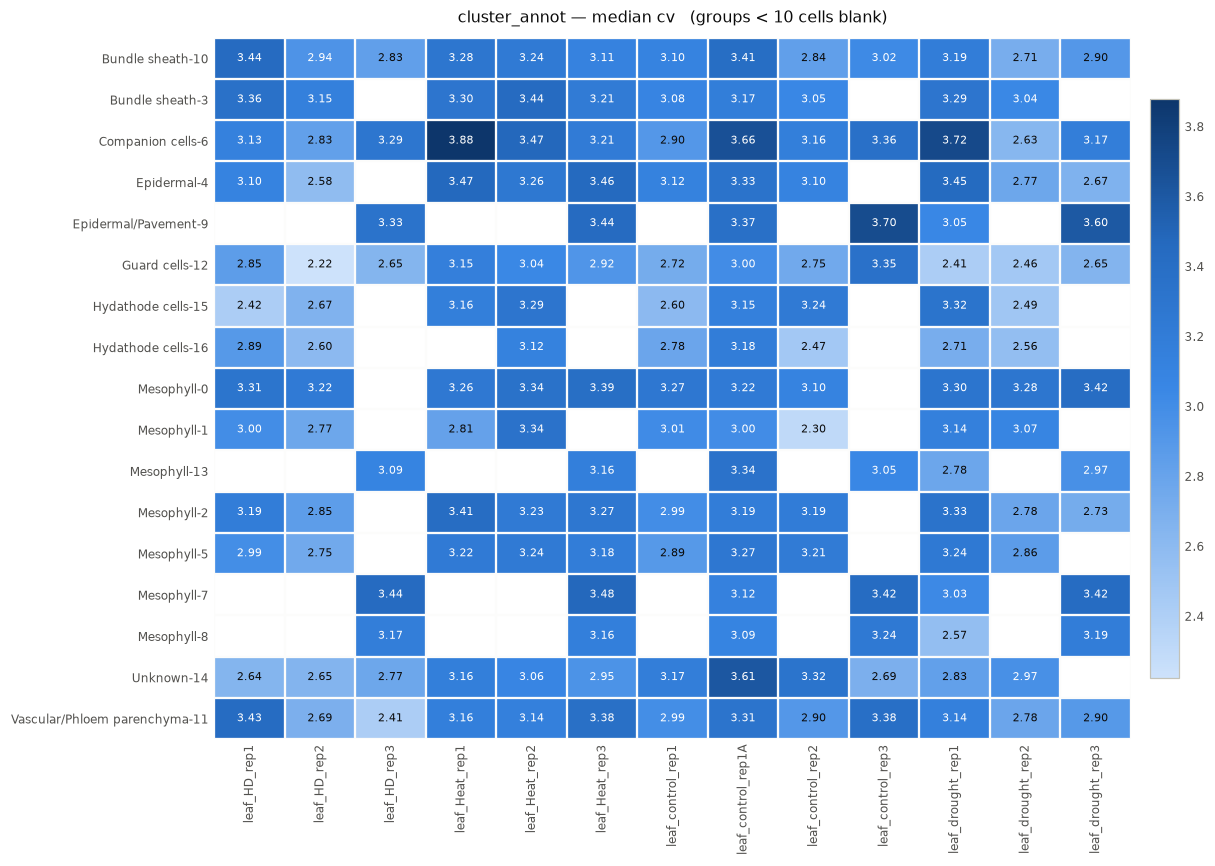

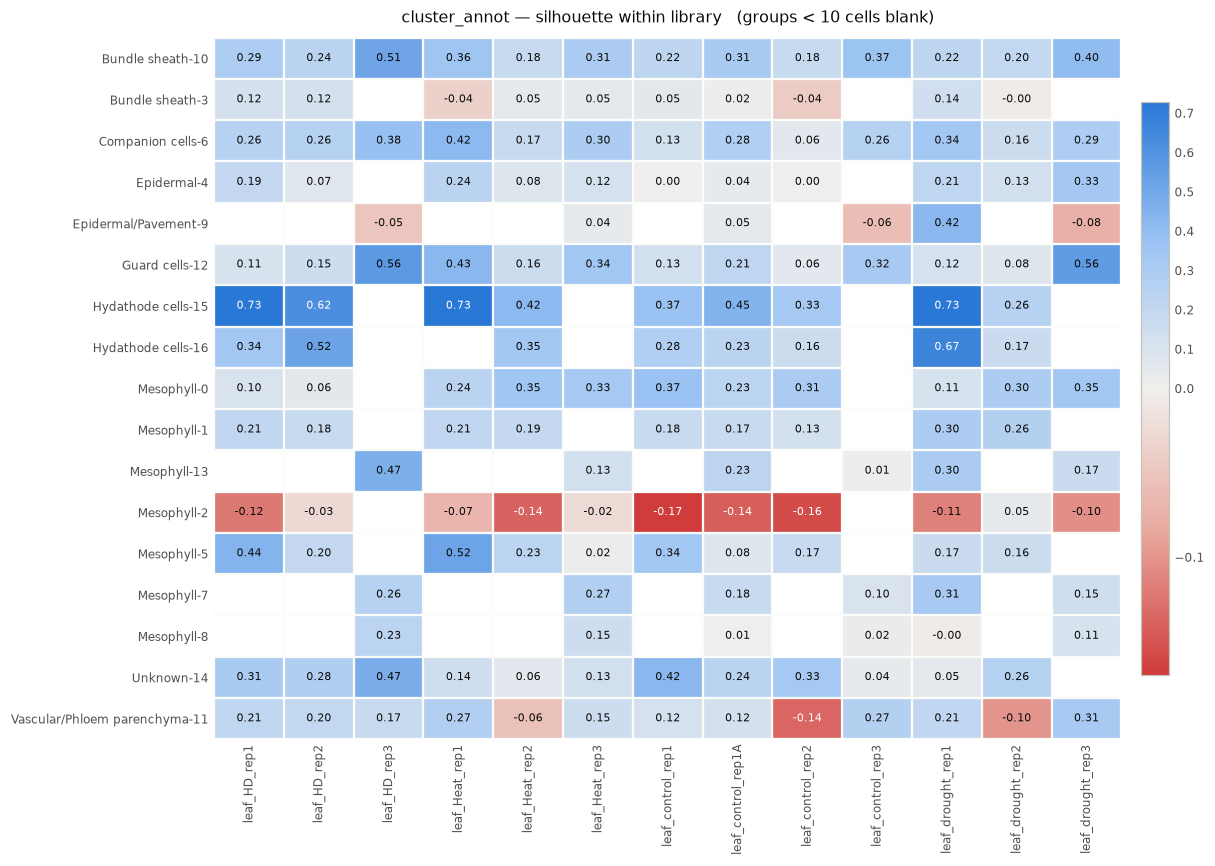

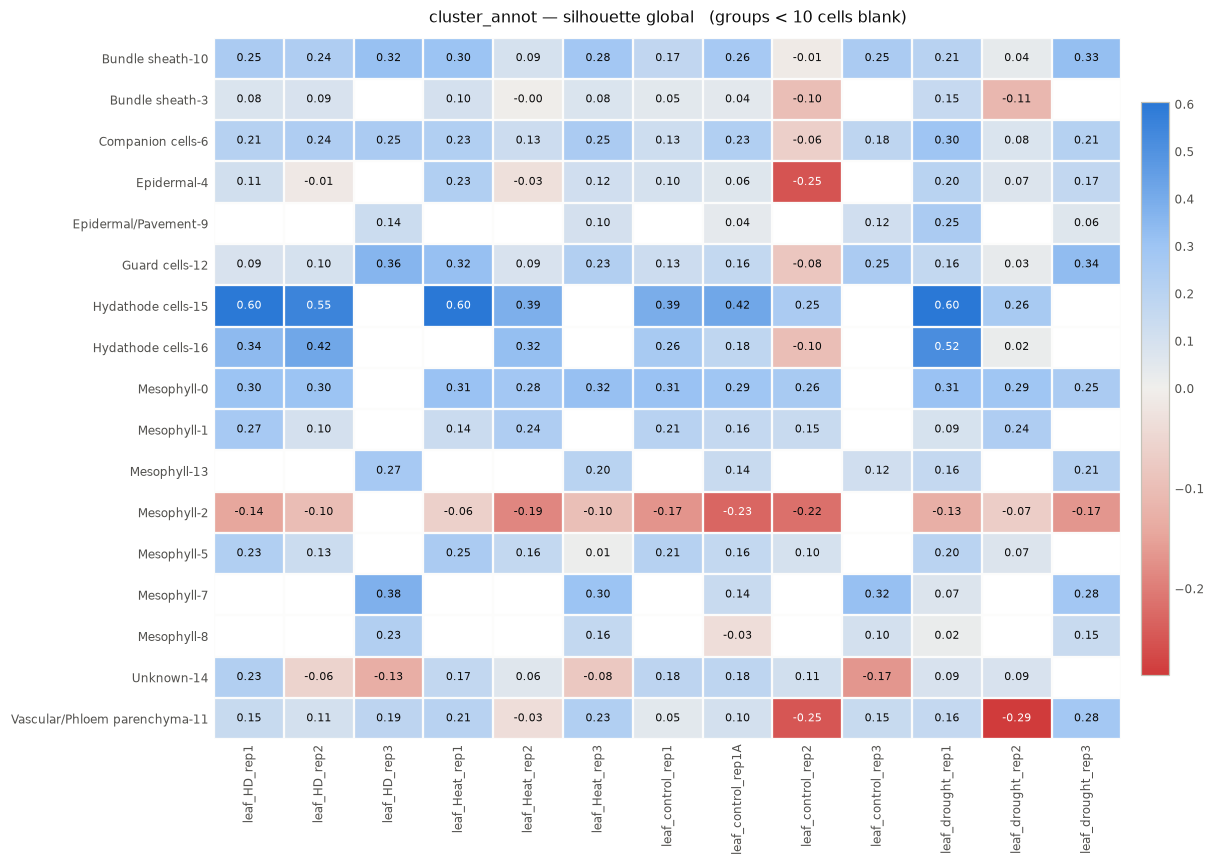

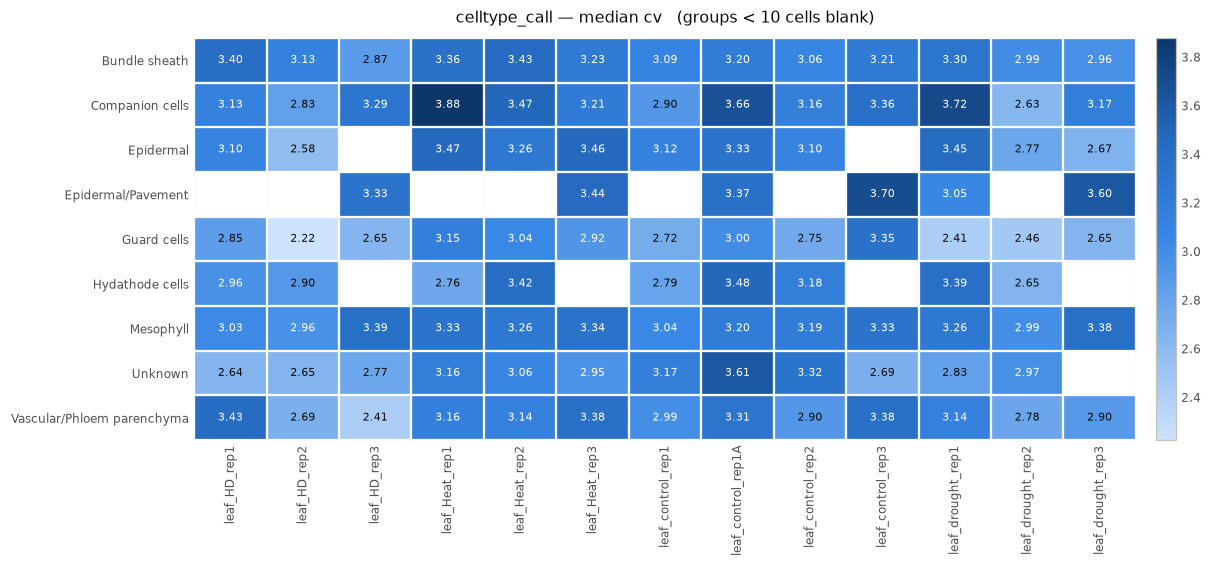

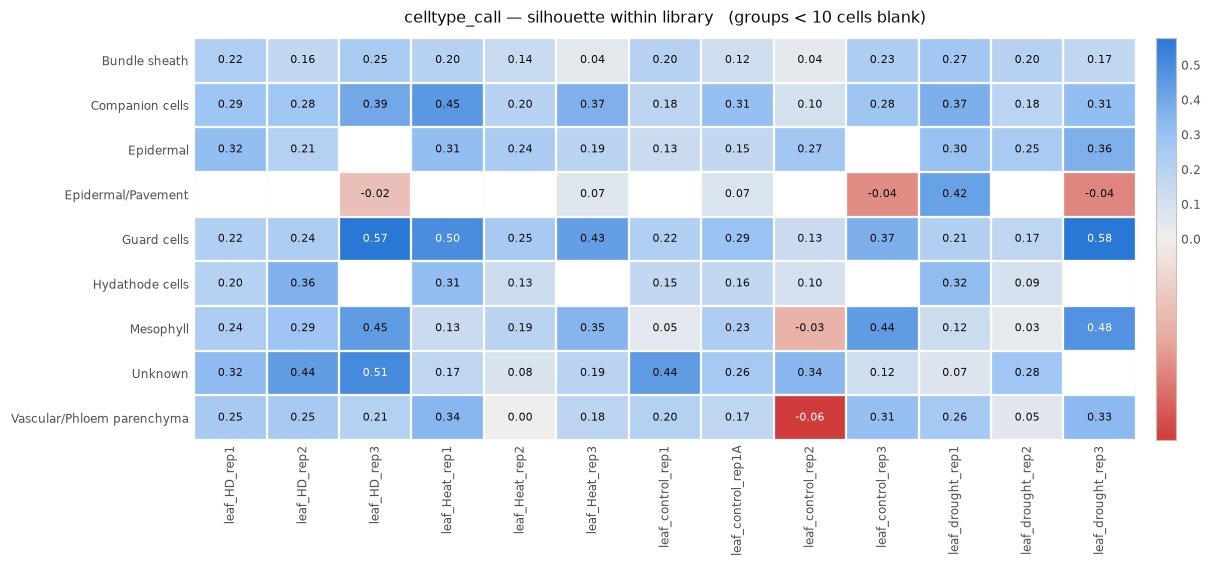

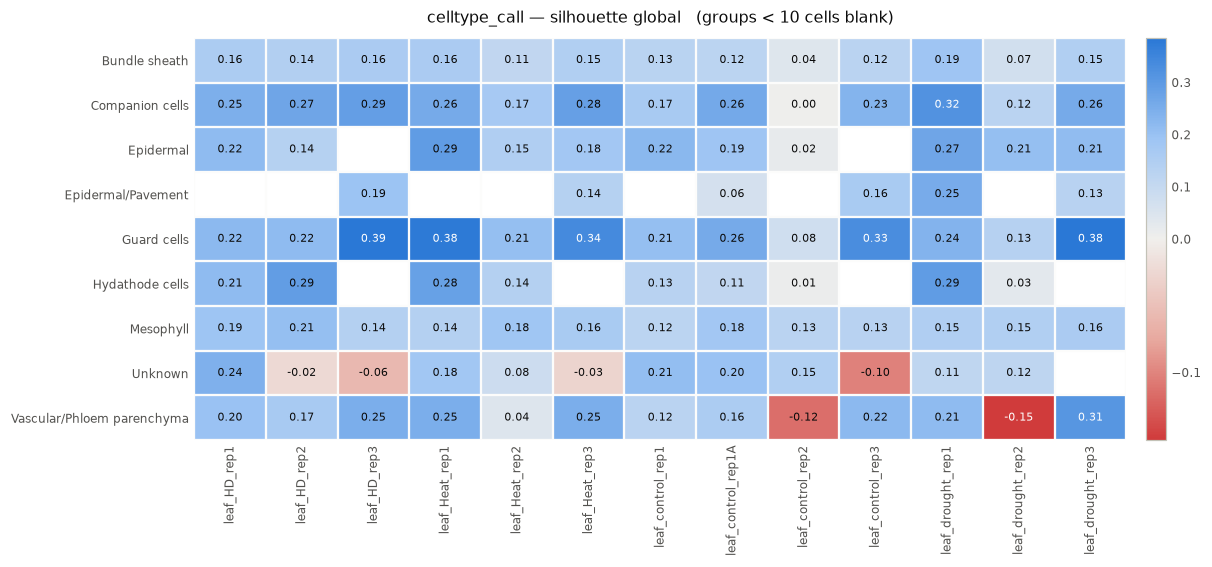

In [12]:
def heatmap(frame, value, cluster_key, cmap, norm=None, fmt="{:.2f}"):
    """cluster x library grid of one metric, blank where the group is too small."""
    sub = frame[
        (frame["clustering"] == cluster_key) & (frame["n_cells"] >= MIN_CELLS_REPORT)
    ]
    grid = sub.pivot(index="cluster", columns=LIBRARY_KEY, values=value).sort_index()
    data = np.ma.masked_invalid(grid.to_numpy(dtype=float))
    mask = np.ma.getmaskarray(data)

    # one panel per metric: 13 libraries do not leave room for legible cell labels side by side
    fig, ax = plt.subplots(
        figsize=(0.55 * grid.shape[1] + 4.0, 0.34 * grid.shape[0] + 2.2)
    )
    im = ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")

    ax.set_xticks(range(grid.shape[1]), grid.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(grid.shape[0]), grid.index, fontsize=8)
    ax.set_xticks(np.arange(-0.5, grid.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0]), minor=True)
    ax.grid(which="minor", color="#fcfcfb", linewidth=1.5)  # surface gap between cells
    ax.grid(which="major", visible=False)
    ax.tick_params(which="both", length=0, colors=SECONDARY_INK)
    ax.set_title(
        f"{cluster_key} — {value.replace('_', ' ')}"
        f"   (groups < {MIN_CELLS_REPORT} cells blank)",
        fontsize=10.5,
        color="#0b0b0b",
        pad=10,
    )
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i, j in np.ndindex(grid.shape):
        if mask[i, j]:
            continue
        red, green, blue, _ = im.cmap(im.norm(data[i, j]))
        luminance = 0.299 * red + 0.587 * green + 0.114 * blue
        ax.text(
            j,
            i,
            fmt.format(data[i, j]),
            ha="center",
            va="center",
            fontsize=7,
            color="#0b0b0b" if luminance > 0.55 else "white",
        )

    fig.colorbar(im, ax=ax, fraction=0.030, pad=0.02).ax.tick_params(
        labelsize=8, length=0, colors=SECONDARY_INK
    )
    fig.tight_layout()
    return fig


for key in CLUSTER_KEYS:
    for value, cmap, cnorm in [("median_cv", SEQ_BLUE, None)] + [
        (c, DIV_BLUE_RED, TwoSlopeNorm(vcenter=0.0)) for c in sil_cols
    ]:
        heatmap(qc, value, key, cmap, norm=cnorm)
        plt.show()

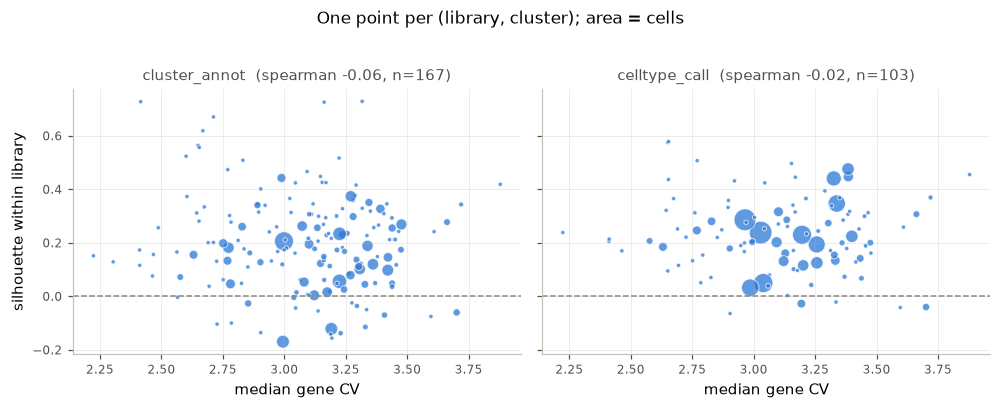

In [13]:
# the two metrics against each other -- they are not measuring the same thing
sil_col = sil_cols[0]
fig, axes = plt.subplots(
    1, len(CLUSTER_KEYS), figsize=(4.6 * len(CLUSTER_KEYS), 3.6), sharey=True
)
for ax, key in zip(np.atleast_1d(axes), CLUSTER_KEYS):
    sub = qc[(qc["clustering"] == key) & (qc["n_cells"] >= MIN_CELLS_REPORT)].dropna(
        subset=["median_cv", sil_col]
    )
    ax.axhline(0, color=MUTED_INK, linewidth=1, linestyle="--")
    ax.scatter(
        sub["median_cv"],
        sub[sil_col],
        s=np.clip(sub["n_cells"] / 12, 8, 220),
        alpha=0.75,
        color=SERIES_COLORS[0],
        edgecolor="white",
        linewidth=0.6,
    )
    rho = sub["median_cv"].corr(sub[sil_col], method="spearman")
    ax.set_title(
        f"{key}  (spearman {rho:.2f}, n={len(sub)})", fontsize=10, color=SECONDARY_INK
    )
    ax.set_xlabel("median gene CV")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.tick_params(labelsize=8, colors=SECONDARY_INK)
np.atleast_1d(axes)[0].set_ylabel(sil_col.replace("_", " "))
fig.suptitle("One point per (library, cluster); area = cells", fontsize=11, y=1.02)
fig.tight_layout()
plt.show()

### How to read this

* **Median CV** is dominated by how highly expressed the panel genes are, so compare *across
  libraries within a cluster* (does one batch make this cluster noisier?) rather than across
  clusters, where a difference can just reflect the expression level of the cluster's marker
  genes. The panel is shared, but the per-group means are not.
* **Silhouette near 0 or negative** means the cluster is not separated from its neighbour in
  `X_pca` — normal for clusters that are subdivisions of one cell type, and a real problem for
  clusters that are supposed to be distinct cell types. Compare `cluster_annot` against
  `celltype_call`: if the 9-level collapse scores much better, the 17-cluster partition is
  splitting cell types more finely than the PCA geometry supports.
* **within-library vs global** — a cluster with a good global silhouette but a poor within-library
  one is held together by cells from *other* libraries; a cluster with the reverse pattern sits in
  a different place in each batch, which is a batch-effect signature.
* **Small groups are unstable.** A cluster with a handful of cells in a library gives a noisy CV
  and a silhouette that sklearn defines as 0 for singletons. `MIN_CELLS_REPORT` blanks those in
  the plots; `n_cells` is in every table.
* Because both metrics are computed per (library, cluster), a cluster that is genuinely absent
  from a library shows up as a blank rather than a bad score — check `n_cells` before reading a
  gap as a quality problem.

### Outputs

`qc_results/cluster_library_qc.csv` — one row per clustering x library x cluster, with `n_cells`,
`median_cv`, `mean_cv`, `genes_used` and the silhouette columns. In memory the same frame is `qc`,
with `cv_results` and `sil_results` as the unmerged pieces.